# Pushbroom Imager Validation: Sentinel-2 MSI

This notebook validates TAT-C's `PointedInstrument` against a pushbroom imager: the Multispectral Instrument (MSI) aboard the European Copernicus [Sentinel-2](https://sentiwiki.copernicus.eu/web/s2-mission) satellites. MSI images a 290 km swath with lines of detectors in its focal plane, one line per band, so the ground is swept by the satellite's motion rather than by a scan mirror. Each line is made of 12 detector modules, staggered alternately forward and aft in the focal plane so that their fields of view overlap.

A rectangular `PointedInstrument` is a rectangle in the plane perpendicular to its boresight, like the focal plane of a camera, so a pushbroom imager is its natural use. The whiskbroom scanner of the [VIIRS](ValidateImagerVIIRS.ipynb) notebook showed where this geometry departs from a scanner's; here it is tested against the instrument it describes. The comparison uses all three Sentinel-2 satellites (2A, 2B, and 2C) on one day and asks four questions:

1. **Orbit.** Does TAT-C's propagation of public two-line element (TLE) sets reproduce the satellites' positions?
2. **Viewing geometry.** What field of view, detector arrangement, and along-track reference direction (velocity frame) describe MSI?
3. **Swath footprints.** Does `compute_ground_track` reproduce the area imaged in each acquisition?
4. **Observation times.** Does `collect_observations` predict when MSI images a point, with a single view and with one view per detector module?

## Reference Data

This notebook uses Level 2A products from the [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a), which provides the SAFE products of the Copernicus Sentinel-2 mission with anonymous access (no account required). Each product is a 110 km tile of one acquisition (datatake), processed in segments called datastrips. Three kinds of metadata are used:

* the **catalog** entry of every tile acquired on 3 October 2026, with the footprint of its valid data and the acquisition and datastrip it belongs to;
* the **datastrip metadata**: the sensing start and stop times of each datastrip (read from the start of the file, for all datastrips) and, for one long acquisition per satellite, the satellite's Earth-fixed position and velocity from its GPS receiver at 1 s intervals (in GPS time, 18 s ahead of UTC);
* the **tile metadata** of every fifth tile of those acquisitions: for each band and detector module, the viewing zenith and azimuth angles (the direction from the ground to the satellite) on a 5 km grid. The red band (B04) is used.

The first run downloads about 0.5 GB and takes several minutes; reduced data are cached in a local `data/sentinel2` directory.

The satellites are modeled with TLEs from [CelesTrak](https://celestrak.org/) whose epochs (4 October 2026, 11:20 to 12:20 UTC) follow the analysis day by up to about a day and a half.

In [1]:
import concurrent.futures
import json
import re
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "sentinel2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 3, tzinfo=timezone.utc)
STAC = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
TOKEN = "https://planetarycomputer.microsoft.com/api/sas/v1/token/sentinel-2-l2a"
TLES = {
    "Sentinel-2A": [
        "1 40697U 15028A   26277.51535578  .00000205  00000+0  94862-4 0  9994",
        "2 40697  98.5646 350.7732 0001083  89.0049 271.1258 14.30820153589369",
    ],
    "Sentinel-2B": [
        "1 42063U 17013A   26277.50820593  .00000133  00000+0  67483-4 0  9991",
        "2 42063  98.5691 350.7118 0001149  89.0927 271.0388 14.30818478500277",
    ],
    "Sentinel-2C": [
        "1 60989U 24157A   26277.47326514  .00000038  00000+0  31260-4 0  9993",
        "2 60989  98.5703 350.6835 0001156  81.8213 278.3101 14.30817151108611",
    ],
}
BAND = "3"  # band identifier of B04 in the tile metadata
GPS_UTC = 18  # s


def get(url, **kwargs):
    """HTTP GET, retrying transient failures."""
    for attempt in range(5):
        try:
            response = requests.get(url, timeout=120, **kwargs)
            response.raise_for_status()
            return response
        except requests.RequestException:
            if attempt == 4:
                raise


def strip_namespaces(text):
    return re.sub(r"<(/?)[A-Za-z0-9_]+:", r"<\1", text)


ITEMS_FILE = DATA_DIR / f"s2_items_{DAY:%Y%m%d}.json"
if not ITEMS_FILE.exists():
    body = {"collections": ["sentinel-2-l2a"], "datetime": f"{DAY:%Y-%m-%d}T00:00:00Z/{DAY:%Y-%m-%d}T23:59:59Z", "limit": 1000}
    items, url = [], STAC
    while url:
        page = requests.post(url, json=body, timeout=300).json()
        items += page["features"]
        following = [link for link in page["links"] if link["rel"] == "next"]
        url, body = (following[0]["href"], following[0].get("body", body)) if following else (None, None)
    ITEMS_FILE.write_text(
        json.dumps(
            [
                {
                    "id": i["id"],
                    "geometry": i["geometry"],
                    "platform": i["properties"]["platform"],
                    "datatake": i["properties"]["s2:datatake_id"],
                    "datastrip": i["properties"]["s2:datastrip_id"],
                    "datetime": i["properties"]["datetime"],
                    "granule_metadata": i["assets"]["granule-metadata"]["href"],
                    "datastrip_metadata": i["assets"]["datastrip-metadata"]["href"],
                }
                for i in items
            ]
        )
    )
tiles = pd.DataFrame(json.loads(ITEMS_FILE.read_text()))
tiles["datetime"] = pd.to_datetime(tiles["datetime"], utc=True)
tiles.groupby("platform").agg(tiles=("id", "size"), datatakes=("datatake", "nunique"), datastrips=("datastrip", "nunique"))

,tiles,datatakes,datastrips
platform,,,
Sentinel-2A,1783,12,19
Sentinel-2B,4125,32,54
Sentinel-2C,4299,25,49


The sensing start and stop times of every datastrip are read from the first 16 kB of its metadata, and the acquisition with the most tiles of each satellite is selected for the detailed comparisons.

In [2]:
DATASTRIPS_FILE = DATA_DIR / f"s2_datastrips_{DAY:%Y%m%d}.csv"
if not DATASTRIPS_FILE.exists():
    token = get(TOKEN).json()["token"]

    def read_times(row):
        head = get(f"{row.datastrip_metadata}?{token}", headers={"Range": "bytes=0-16383"}).text
        times = {tag: re.search(f"<{tag}>(.*?)</{tag}>", head).group(1) for tag in ["DATASTRIP_SENSING_START", "DATASTRIP_SENSING_STOP"]}
        return {"datastrip": row.datastrip, "start": times["DATASTRIP_SENSING_START"], "stop": times["DATASTRIP_SENSING_STOP"]}

    first = tiles.drop_duplicates("datastrip")
    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        pd.DataFrame(pool.map(read_times, first.itertuples())).to_csv(DATASTRIPS_FILE, index=False)
datastrips = pd.read_csv(DATASTRIPS_FILE, parse_dates=["start", "stop"]).merge(
    tiles.groupby("datastrip").agg(platform=("platform", "first"), datatake=("datatake", "first"), tiles=("id", "size")).reset_index()
)
selected = tiles.groupby(["platform", "datatake"]).size().reset_index(name="tiles").sort_values("tiles").groupby("platform").tail(1)
selected

,platform,datatake,tiles
4,Sentinel-2A,GS2A_20261003T082021_058920_N05.13,548
54,Sentinel-2C,GS2C_20261003T085811_010845_N05.13,560
28,Sentinel-2B,GS2B_20261003T080749_050011_N05.13,609


For the selected acquisitions, the GPS ephemeris of each datastrip and the B04 viewing angle grids of every fifth tile (in time order) are downloaded and cached.

In [3]:
EPHEMERIS_FILE = DATA_DIR / f"s2_ephemeris_{DAY:%Y%m%d}.csv"
GRIDS_FILE = DATA_DIR / f"s2_viewing_grids_{DAY:%Y%m%d}.csv"
if not (EPHEMERIS_FILE.exists() and GRIDS_FILE.exists()):
    from pyproj import Transformer

    token = get(TOKEN).json()["token"]
    chosen = tiles[tiles.datatake.isin(selected.datatake)]

    def read_ephemeris(row):
        root = ET.fromstring(strip_namespaces(get(f"{row.datastrip_metadata}?{token}").text))
        return pd.DataFrame(
            {
                "platform": row.platform,
                "datastrip": row.datastrip,
                "time": [pd.Timestamp(p.find("GPS_TIME").text, tz="UTC") - pd.Timedelta(seconds=GPS_UTC) for p in root.findall(".//GPS_Point")],
                **{
                    f"{kind}_{axis}": [float(p.find(f"{kind.upper()}_VALUES").text.split()[i]) / 1e3 for p in root.findall(".//GPS_Point")]
                    for kind in ["position", "velocity"]
                    for i, axis in enumerate("xyz")
                },
            }
        )

    def read_grids(row):
        root = ET.fromstring(strip_namespaces(get(f"{row.granule_metadata}?{token}").text))
        epsg = int(root.find(".//HORIZONTAL_CS_CODE").text.split(":")[1])
        geoposition = next(g for g in root.findall(".//Geoposition") if g.get("resolution") == "10")
        ulx, uly = float(geoposition.find("ULX").text), float(geoposition.find("ULY").text)
        to_lonlat = Transformer.from_crs(epsg, 4326, always_xy=True)
        records = []
        for grid in root.findall(".//Viewing_Incidence_Angles_Grids"):
            if grid.get("bandId") != BAND:
                continue
            zenith = np.array([[float(v) for v in r.text.split()] for r in grid.find("Zenith/Values_List")])
            azimuth = np.array([[float(v) for v in r.text.split()] for r in grid.find("Azimuth/Values_List")])
            i, j = np.nonzero(np.isfinite(zenith))
            lon, lat = to_lonlat.transform(ulx + j * 5000.0, uly - i * 5000.0)
            records.append(
                pd.DataFrame(
                    {"tile": row.id, "platform": row.platform, "datastrip": row.datastrip, "detector": int(grid.get("detectorId")),
                     "lon": lon, "lat": lat, "zenith": zenith[i, j], "azimuth": azimuth[i, j]}
                )
            )
        # tiles without valid data have no viewing grids
        return pd.concat(records) if records else None

    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        ephemeris = pd.concat(pool.map(read_ephemeris, chosen.drop_duplicates("datastrip").itertuples()))
        sampled = pd.concat([g.sort_values("datetime").iloc[::5] for _, g in chosen.groupby("datatake")])
        grids = pd.concat(pool.map(read_grids, sampled.itertuples()))
    ephemeris.to_csv(EPHEMERIS_FILE, index=False)
    grids.to_csv(GRIDS_FILE, index=False)

ephemeris = pd.read_csv(EPHEMERIS_FILE, parse_dates=["time"])
grids = pd.read_csv(GRIDS_FILE)
pd.Series(
    {
        "GPS ephemeris points": len(ephemeris),
        "tiles with viewing grids": grids.tile.nunique(),
        "viewing grid points (B04)": len(grids),
    }
)

GPS ephemeris points           6826
tiles with viewing grids        343
viewing grid points (B04)    131065
dtype: int64

## Setup

Times are converted to seconds since 00:00 UTC on the analysis day. Helper functions match those of the companion notebooks.

In [4]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import shapely
import shapely.ops
from pyproj import Transformer
from shapely.geometry import shape
from skyfield.framelib import itrs

from tatc.analysis import collect_observations, compute_ground_track
from tatc.constants import EARTH_ROTATION_RATE
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, PointedInstrument, Satellite
from tatc.utils import NadirReference, VelocityFrame

TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
satellites = {name: Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle(tle)) for name, tle in TLES.items()}
PLATFORMS = list(TLES)


def seconds(times):
    """Seconds since the start of the analysis day."""
    delta = pd.to_datetime(times, utc=True) - pd.Timestamp(DAY)
    return delta.dt.total_seconds().to_numpy() if isinstance(delta, pd.Series) else delta.total_seconds()


def to_utc(values):
    return [DAY + timedelta(seconds=float(s)) for s in np.atleast_1d(values)]


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack([-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


ephemeris["t"] = seconds(ephemeris["time"])
BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
PLATFORM_COLORS = dict(zip(PLATFORMS, [BLUE, ORANGE, AQUA]))
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## Test 1: Orbit

TAT-C's propagated positions are compared with the GPS ephemeris of the selected acquisitions, with residuals decomposed along the velocity, to its right, and radially.

In [5]:
rows1 = {}
for platform in PLATFORMS:
    e = ephemeris[ephemeris.platform == platform].iloc[::10]
    position = e[[f"position_{a}" for a in "xyz"]].to_numpy()
    velocity = e[[f"velocity_{a}" for a in "xyz"]].to_numpy()
    predicted = np.array(satellites[platform].orbit.to_gp_orbit().get_orbit_track(to_utc(e.t)).frame_xyz_and_velocity(itrs)[0].m).T
    offset = predicted - position
    radial = normalize(position)
    along = normalize(velocity - np.sum(velocity * radial, axis=-1, keepdims=True) * radial)
    for name, component in [("along-track", along), ("cross-track, right", np.cross(along, radial)), ("radial", radial)]:
        rows1[(platform, f"{name} (km)")] = summarize(np.sum(offset * component, axis=-1) / 1e3)
pd.DataFrame(rows1).T.round(3)

n  median  p95 |x|  max |x|
Sentinel-2A along-track (km)         213.0   0.178    0.464    0.494
            cross-track, right (km)  213.0   0.116    0.139    0.139
            radial (km)              213.0  -0.147    0.168    0.168
Sentinel-2B along-track (km)         253.0   0.106    0.410    0.448
            cross-track, right (km)  253.0   0.116    0.143    0.143
            radial (km)              253.0  -0.140    0.169    0.169
Sentinel-2C along-track (km)         218.0   0.159    0.472    0.516
            cross-track, right (km)  218.0   0.068    0.084    0.084
            radial (km)              218.0  -0.135    0.199    0.199

The propagated TLEs match the GPS positions to within 0.5 km along track and 0.2 km across track and radially, a day or more before the TLE epochs. At MSI's ground speed of 6.6 km/s, the along-track offset corresponds to less than 0.1 s, negligible in the tests that follow.

## Test 2: Viewing Geometry

Each viewing grid point gives the direction from the ground (on the WGS 84 ellipsoid) to the satellite. Following that direction to the satellite's geocentric radius locates the satellite, and the time at which the GPS ephemeris passes closest to that location is the time the point was imaged. The line of sight from the satellite at that time to the point is then decomposed into TAT-C's along-track and cross-track view angles (the arctangents of `compute_view_tangents`, positive forward and to the left), relative to both the Earth-fixed and the inertial velocity. Like TAT-C, the decomposition takes nadir as the geodetic vertical (the ellipsoid normal at the sub-satellite point); for comparison, it is repeated with the geocentric nadir (toward the Earth's center).

The along-track view angles are fit with a separate offset for each detector module plus terms linear (a yaw of the detector lines) and quadratic (a curvature, or smile) in the cross-track view angle.

In [6]:
def recover(platform_grids):
    """Imaging time (s) and along- and cross-track view angles (deg) of viewing grid points, in both velocity frames."""
    platform = platform_grids.platform.iloc[0]
    e = ephemeris[ephemeris.platform == platform].sort_values("t").drop_duplicates("t")
    t_e = e.t.to_numpy()
    position_e = e[[f"position_{a}" for a in "xyz"]].to_numpy()
    velocity_e = e[[f"velocity_{a}" for a in "xyz"]].to_numpy()
    interpolate = lambda t, values: np.stack([np.interp(t, t_e, values[:, k]) for k in range(3)], axis=-1)
    lon, lat = platform_grids.lon.to_numpy(), platform_grids.lat.to_numpy()
    point = ecef(lon, lat)
    u, east = up(lon, lat), normalize(np.stack([-np.sin(np.radians(lon)), np.cos(np.radians(lon)), 0 * lon], axis=-1))
    north = np.cross(u, east)
    zenith, azimuth = np.radians(platform_grids.zenith.to_numpy())[:, None], np.radians(platform_grids.azimuth.to_numpy())[:, None]
    toward = np.cos(zenith) * u + np.sin(zenith) * (np.sin(azimuth) * east + np.cos(azimuth) * north)
    b = np.sum(point * toward, axis=1)
    t = np.full(len(point), np.median(t_e))
    for _ in range(8):
        p, v = interpolate(t, position_e), interpolate(t, velocity_e)
        radius = np.linalg.norm(p, axis=1)
        location = point + (-b + np.sqrt(b**2 - np.sum(point**2, axis=1) + radius**2))[:, None] * toward
        t = t - np.sum((p - location) * v, axis=1) / np.sum(v * v, axis=1)
    p, v = interpolate(t, position_e), interpolate(t, velocity_e)
    los = normalize(point - p)
    sub_lon, sub_lat, _ = TO_GEODETIC.transform(*p.T)
    nadir = -up(sub_lon, sub_lat)
    result = {"t": t, "miss": np.linalg.norm(np.cross(p - location, normalize(v)), axis=1) / 1e3}
    for frame, velocity, nadir in [("earth_fixed", v, nadir), ("inertial", inertial_velocity(p, v), nadir), ("geocentric", v, -normalize(p))]:
        cross_axis = normalize(np.cross(velocity, nadir))
        along_axis = np.cross(nadir, cross_axis)
        down = np.sum(los * nadir, axis=1)
        result[f"along_{frame}"] = np.degrees(np.arctan(np.sum(los * along_axis, axis=1) / down))
        result[f"cross_{frame}"] = np.degrees(np.arctan(np.sum(los * cross_axis, axis=1) / down))
    return pd.DataFrame(result, index=platform_grids.index)


grids = grids.join(pd.concat([recover(g) for _, g in grids.groupby("platform")]))
grids["odd"] = grids.detector % 2 == 1


def fit(frame):
    """Per-detector along-track angle offsets plus common linear (yaw) and quadratic terms in the cross-track angle."""
    x = grids[f"cross_{frame}"].to_numpy()
    design = np.column_stack([pd.get_dummies(grids.detector).to_numpy(float), x, x**2])
    coefficients, *_ = np.linalg.lstsq(design, grids[f"along_{frame}"].to_numpy(), rcond=None)
    residual = grids[f"along_{frame}"].to_numpy() - design @ coefficients
    return coefficients, residual


rows2 = {}
for frame, label in [("earth_fixed", "earth_fixed"), ("inertial", "inertial"), ("geocentric", "earth_fixed, geocentric nadir")]:
    coefficients, residual = fit(frame)
    grids[f"residual_{frame}"] = residual
    rows2[label] = {
        "yaw of detector lines (deg)": np.degrees(np.arctan(coefficients[-2])),
        "along-track curvature (deg per deg^2)": coefficients[-1],
        "fit residual, p95 (deg)": np.percentile(np.abs(residual), 95),
    }
detectors = grids.groupby("detector").agg(
    along=("along_earth_fixed", "median"), cross_min=("cross_earth_fixed", "min"), cross_max=("cross_earth_fixed", "max"), points=("t", "size")
)
pd.concat(
    [
        pd.DataFrame(rows2).T.round(4),
        pd.DataFrame(
            {
                "value": {
                    "imaging time recovery, miss distance p95 (km)": np.percentile(grids.miss, 95),
                    "cross-track view angle, minimum (deg)": grids.cross_earth_fixed.min(),
                    "cross-track view angle, maximum (deg)": grids.cross_earth_fixed.max(),
                    "odd detectors, along-track angle (deg)": grids[grids.odd].along_earth_fixed.median(),
                    "even detectors, along-track angle (deg)": grids[~grids.odd].along_earth_fixed.median(),
                }
            }
        ).round(3),
    ]
)

,yaw of detector lines (deg),along-track curvature (deg per deg^2),"fit residual, p95 (deg)",value
earth_fixed,0.5008,0.0023,0.2049,NaN
inertial,3.2040,0.0027,0.2879,NaN
"earth_fixed, geocentric nadir",-0.1301,0.0025,0.0728,NaN
"imaging time recovery, miss distance p95 (km)",NaN,NaN,NaN,0.190
"cross-track view angle, minimum (deg)",NaN,NaN,NaN,-10.563
"cross-track view angle, maximum (deg)",NaN,NaN,NaN,10.539
"odd detectors, along-track angle (deg)",NaN,NaN,NaN,-0.924
"even detectors, along-track angle (deg)",NaN,NaN,NaN,1.022


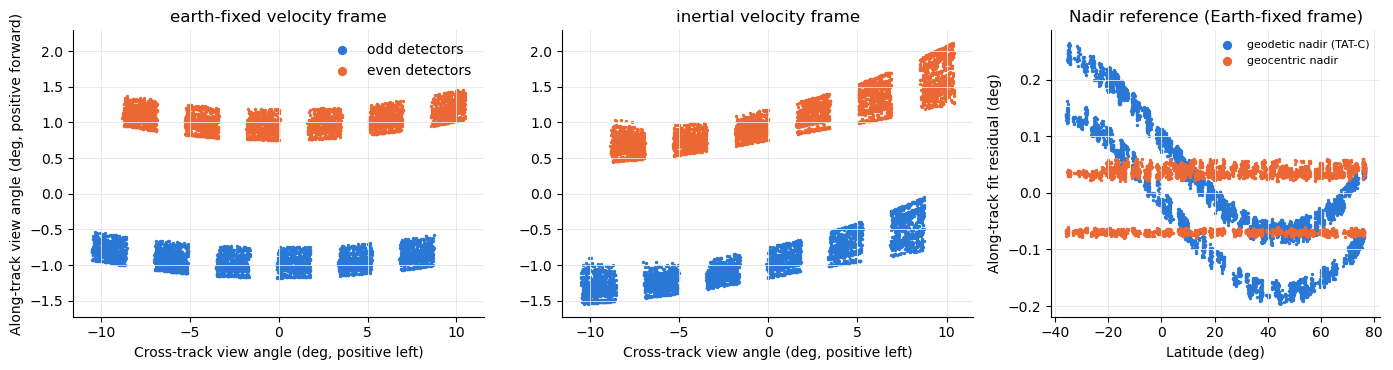

detector,1,2,3,4,5,6,7,8,9,10,11,12
along,-0.823,1.067,-0.952,0.947,-1.011,0.912,-1.020,0.933,-0.968,1.021,-0.872,1.165
cross_min,-10.563,-8.821,-7.043,-5.317,-3.575,-1.859,-0.128,1.593,3.310,5.046,6.780,8.544
cross_max,-8.565,-6.837,-5.074,-3.351,-1.627,0.088,1.806,3.543,5.259,7.004,8.761,10.539
points,12472.000,12202.000,11282.000,10720.000,9995.000,10233.000,10627.000,10858.000,10868.000,10616.000,10420.000,10772.000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1, 1, 0.8]})
for ax, frame in zip(axes[:2], ["earth_fixed", "inertial"]):
    for odd, color, label in [(True, BLUE, "odd detectors"), (False, ORANGE, "even detectors")]:
        g = grids[grids.odd == odd].sample(min(4000, int((grids.odd == odd).sum())), random_state=0)
        ax.scatter(g[f"cross_{frame}"], g[f"along_{frame}"], s=2, color=color, label=label)
    ax.set(xlabel="Cross-track view angle (deg, positive left)", title=f"{frame.replace('_', '-')} velocity frame")
axes[1].sharey(axes[0])
axes[0].set_ylabel("Along-track view angle (deg, positive forward)")
axes[0].legend(frameon=False, markerscale=4)
g = grids.sample(6000, random_state=0)
for frame, color, label in [("earth_fixed", BLUE, "geodetic nadir (TAT-C)"), ("geocentric", ORANGE, "geocentric nadir")]:
    axes[2].scatter(g.lat, g[f"residual_{frame}"], s=2, color=color, label=label)
axes[2].set(xlabel="Latitude (deg)", ylabel="Along-track fit residual (deg)", title="Nadir reference (Earth-fixed frame)")
axes[2].legend(frameon=False, markerscale=4, fontsize=8)
fig.tight_layout()
plt.show()
detectors.round(3).T

The B04 detector lines span cross-track view angles of -10.56 to +10.54 deg (a 21.1 deg field of view centered on nadir) in 12 modules of about 2 deg, each overlapping its neighbors by about 0.25 deg. Odd modules look about 0.9 deg aft and even modules about 1.0 deg forward of nadir, so a ground point is imaged by an odd module about 4 s after an even module (2 deg subtends about 28 km at nadir).

In the Earth-fixed velocity frame, each module's line is nearly perpendicular to the ground track: the fit yaw is 0.5 deg, and the lines curve slightly forward toward the swath edges (0.0023 deg per deg squared, or 0.25 deg at the edges). In the inertial frame, the lines are rotated by 3.2 deg, the yaw steering that Sentinel-2 applies to compensate for the Earth's rotation. As for the yaw-steered SAR missions, the **Earth-fixed velocity frame** (TAT-C's default) describes MSI.

The remaining structure is a slowly varying along-track offset of up to 0.2 deg that changes with latitude (right panel). It disappears when the angles are measured from the geocentric nadir: the residuals then reduce to a constant offset between satellites (Sentinel-2B looks about 0.1 deg further aft than 2A and 2C), the fit yaw reduces to -0.13 deg, and the 95th percentile residual drops from 0.20 to 0.07 deg. Sentinel-2's pointing therefore follows the geocentric rather than the geodetic vertical, which differ by up to 0.19 deg at mid-latitudes. With TAT-C's default geodetic nadir reference, this appears as a pitch of up to 0.2 deg (2.8 km along track, 0.4 s) that changes sign across the equator; instruments can instead use a geocentric nadir reference (`nadir_reference`), as tested in Test 4.

## Test 3: Swath Footprints

For every datastrip, the union of its tiles' valid data footprints (from the catalog) is compared with the union of TAT-C footprints from `compute_ground_track` between its sensing start and stop times, in an azimuthal equidistant projection centered on the datastrip. The `PointedInstrument` spans the measured cross-track view angles (Test 2) in the Earth-fixed velocity frame, with time steps of about 10 s and the along-track field of view tailored to the time step (the angle subtended at nadir by the distance the ground track advances in one time step). For comparison, the same view in the inertial velocity frame is also evaluated.

In [8]:
TIME_STEP = 10  # s
cross_fov = grids.cross_earth_fixed.max() - grids.cross_earth_fixed.min()
roll = (grids.cross_earth_fixed.max() + grids.cross_earth_fixed.min()) / 2
altitude = float(np.median(np.linalg.norm(ephemeris[[f"position_{a}" for a in "xyz"]].to_numpy(), axis=1))) - 6371.0088e3
ground_speed = 2 * np.pi * 6371.0088e3 / (86400 / float(TLES["Sentinel-2A"][1][52:63]))


def msi_view(time_step, velocity_frame=VelocityFrame.EARTH_FIXED):
    return PointedInstrument(
        name="MSI",
        field_of_regard=cross_fov + 10,
        cross_track_field_of_view=cross_fov,
        along_track_field_of_view=np.degrees(2 * np.arctan(ground_speed * time_step / 2 / altitude)),
        roll_angle=roll,
        is_rectangular=True,
        velocity_frame=velocity_frame,
    )


def unwrap(geometry):
    """Shift longitudes of geometries that cross the antimeridian to be continuous."""
    lon = np.concatenate([np.array(g.exterior.coords)[:, 0] for g in getattr(geometry, "geoms", [geometry])])
    if lon.max() - lon.min() > 180:
        return shapely.ops.transform(lambda x, y, z=None: (np.where(np.asarray(x) < 0, np.asarray(x) + 360, x), y), geometry)
    return geometry


def footprint_row(row):
    observed = unwrap(shapely.unary_union([shape(g) for g in tiles.geometry[tiles.datastrip == row.datastrip]]))
    center = observed.centroid
    project = Transformer.from_crs("EPSG:4326", f"+proj=aeqd +lat_0={center.y} +lon_0={center.x} +units=m", always_xy=True).transform
    a = shapely.ops.transform(project, observed).buffer(0)
    start, stop = seconds(row.start), seconds(row.stop)
    n = max(1, int(round((stop - start) / TIME_STEP)))
    step = (stop - start) / n
    times = to_utc(start + step * (np.arange(n) + 0.5))
    result = {"datastrip": row.datastrip, "platform": row.platform, "tiles": row.tiles, "duration (s)": stop - start, "latitude": center.y}
    for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]:
        satellite = satellites[row.platform].model_copy(update={"instruments": [msi_view(step, frame)]})
        predicted = compute_ground_track(satellite, times).geometry.iloc[0]
        b = shapely.ops.transform(project, unwrap(predicted)).buffer(0)
        result[f"IoU, {frame.value}"] = a.intersection(b).area / a.union(b).area
        result[f"observed only (%), {frame.value}"] = 100 * a.difference(b).area / a.area
        result[f"TAT-C only (%), {frame.value}"] = 100 * b.difference(a).area / b.area
    return result


footprints = pd.DataFrame([footprint_row(row) for row in datastrips.itertuples()])
pd.concat(
    [
        footprints.drop(columns=["datastrip", "platform"]).describe(percentiles=[0.05, 0.5]).T[["count", "5%", "50%", "mean"]],
    ]
).round(3)

,count,5%,50%,mean
tiles,122.0,9.000,67.500,83.664
duration (s),122.0,14.432,193.016,254.259
latitude,122.0,-74.661,19.775,17.823
"IoU, earth_fixed",122.0,0.688,0.957,0.919
"observed only (%), earth_fixed",122.0,0.068,0.857,0.880
"TAT-C only (%), earth_fixed",122.0,1.331,3.362,7.296
"IoU, inertial",122.0,0.676,0.956,0.916
"observed only (%), inertial",122.0,0.218,1.040,1.150
"TAT-C only (%), inertial",122.0,1.350,3.496,7.507


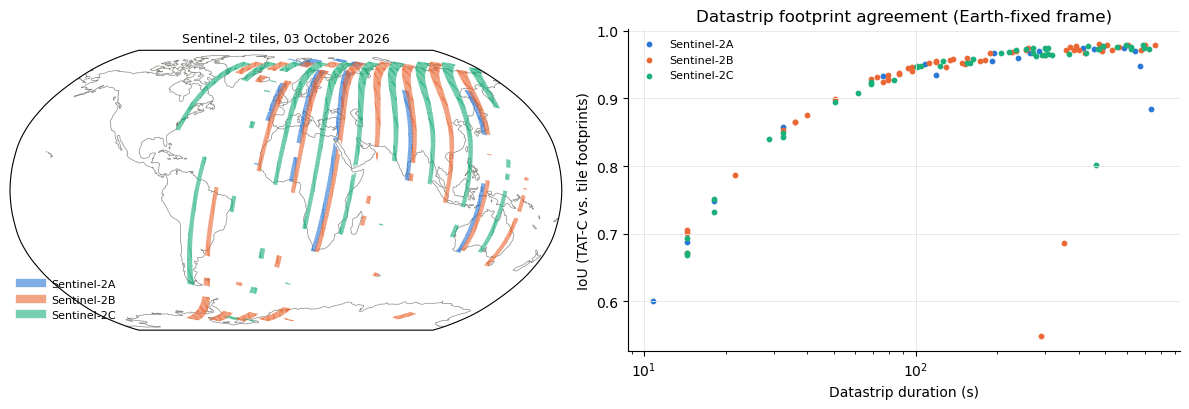

In [9]:
fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
for platform in PLATFORMS:
    geometries = [shape(g) for g in tiles.geometry[tiles.platform == platform]]
    ax.add_geometries(geometries, crs=ccrs.PlateCarree(), facecolor=PLATFORM_COLORS[platform], edgecolor="none", alpha=0.6)
    ax.plot([], [], color=PLATFORM_COLORS[platform], lw=6, alpha=0.6, label=platform)
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.set_title(f"Sentinel-2 tiles, {DAY:%d %B %Y}", fontsize=9)
ax2 = fig.add_subplot(1, 2, 2)
for platform in PLATFORMS:
    f = footprints[footprints.platform == platform]
    ax2.scatter(f["duration (s)"], f["IoU, earth_fixed"], s=10, color=PLATFORM_COLORS[platform], label=platform)
ax2.set(xscale="log", xlabel="Datastrip duration (s)", ylabel="IoU (TAT-C vs. tile footprints)", title="Datastrip footprint agreement (Earth-fixed frame)")
ax2.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Of the 122 datastrips acquired on 3 October 2026, half have footprints that match the observed area with an IoU of at least 0.957, and those longer than about 100 s (650 km) generally exceed 0.94. Very little of the observed area falls outside the TAT-C footprint (0.9%, median). The differences are mostly TAT-C footprint area beyond the observed area, explained by two effects (a least-squares fit across datastrips of the percentage of TAT-C area outside the observed area gives a constant 1.8% plus 4.1 s divided by the datastrip duration):

* **Swath width.** The TAT-C swath spans the measured B04 view angles, 296 km at the satellites' 795 km altitude, about 2% wider than the 290 km nominal swath in which all bands have valid data.
* **Datastrip ends.** TAT-C images the full swath for the whole sensing interval, but the observed area in which all bands have valid data is shorter by about 4 s (27 km) in total: at each end, the staggered modules (about 2 deg, or 4 s, between odd and even modules) and the bands' positions in the focal plane leave sawtooth edges imaged by only some detectors. This dominates short datastrips: the many 14 s datastrips (one row of tiles) have IoUs of 0.67 to 0.75.

The two long datastrips with IoUs below 0.7 are missing tiles over open water (the Gulf of Oman and the Red Sea), so the observed area is incomplete rather than the TAT-C footprint wrong.

The inertial velocity frame performs almost identically (median IoU 0.956): a 3 deg yaw shifts the swath edges by only about 7 km along track, small compared to the datastrip lengths. The footprint comparison is insensitive to the velocity frame; observation times (Test 4) are not.

## Test 4: Observation Times

Each viewing grid point is a ground point with a known imaging time (Test 2). For about 1,000 evenly sampled grid points, `collect_observations` is run over a window of 10 minutes around the imaging time, and the observation epoch nearest the imaging time is compared with it, for several representations of MSI:

* a **single view**: the rectangular `PointedInstrument` of Test 3, in each velocity frame;
* a **nadir field of regard**: an `Instrument` whose field of regard spans the swath (whose epoch is the time of closest approach); and
* **detector views**: one rectangular `PointedInstrument` per detector module, rolled to the center of the module's measured cross-track view angles and pitched to its measured along-track view angle (Test 2), with a 1 deg along-track field of view; a point's epoch is that of the module whose view contains it. The detector views are evaluated with TAT-C's default geodetic nadir reference and, with view angles measured from the geocentric nadir, with a geocentric nadir reference (`nadir_reference`).

In [10]:
single = {frame.value: msi_view(TIME_STEP, frame) for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]}
nadir = Instrument(name="MSI", field_of_regard=2 * max(abs(grids.cross_earth_fixed.min()), grids.cross_earth_fixed.max()))
modules = [
    PointedInstrument(
        name=f"MSI detector {d}",
        field_of_regard=cross_fov + 10,
        cross_track_field_of_view=row.cross_max - row.cross_min,
        along_track_field_of_view=1,
        roll_angle=(row.cross_max + row.cross_min) / 2,
        pitch_angle=row.along,
        is_rectangular=True,
    )
    for d, row in detectors.iterrows()
]
# the same, with the view angles measured from (and the views rotated from) the geocentric nadir
detectors_geocentric = grids.groupby("detector").agg(along=("along_geocentric", "median"), cross_min=("cross_geocentric", "min"), cross_max=("cross_geocentric", "max"))
modules_geocentric = [
    PointedInstrument(
        name=f"MSI detector {d}",
        field_of_regard=cross_fov + 10,
        cross_track_field_of_view=row.cross_max - row.cross_min,
        along_track_field_of_view=1,
        roll_angle=(row.cross_max + row.cross_min) / 2,
        pitch_angle=row.along,
        is_rectangular=True,
        nadir_reference=NadirReference.GEOCENTRIC,
    )
    for d, row in detectors_geocentric.iterrows()
]
sample4 = grids.iloc[:: max(1, len(grids) // 1000)]
rows4, dt4 = {}, {}
for name, instruments in [
    ("single view, earth_fixed", [single["earth_fixed"]]),
    ("single view, inertial", [single["inertial"]]),
    ("nadir field of regard", [nadir]),
    ("detector views", modules),
    ("detector views, geocentric nadir", modules_geocentric),
]:
    differences, missed = [], 0
    for point in sample4.itertuples():
        truth = pd.Timestamp(DAY) + pd.Timedelta(seconds=float(point.t))
        satellite = satellites[point.platform].model_copy(update={"instruments": instruments})
        epochs = [
            collect_observations(Point(id=0, latitude=point.lat, longitude=point.lon), satellite, truth - pd.Timedelta(minutes=5), truth + pd.Timedelta(minutes=5), index).epoch
            for index in range(len(instruments))
        ]
        epochs = pd.concat(epochs) if epochs else pd.Series(dtype="datetime64[ns, UTC]")
        if epochs.empty:
            missed += 1
            continue
        delta = (epochs - truth).dt.total_seconds().to_numpy()
        differences.append(delta[np.argmin(np.abs(delta))])
    dt4[name] = np.array(differences)
    lat4 = sample4.lat.to_numpy()
    rows4[name] = pd.concat([pd.Series({"points": len(sample4), "missed": missed}), summarize(differences).drop("n")])
pd.DataFrame(rows4).T.rename(columns={"median": "time, median (s)", "p95 |x|": "time, p95 |x| (s)", "max |x|": "time, max |x| (s)"}).round(3)

,points,missed,"time, median (s)","time, p95 |x| (s)","time, max |x| (s)"
"single view, earth_fixed",1001.0,0.0,-1.239,2.466,3.008
"single view, inertial",1001.0,0.0,-0.225,3.355,4.325
nadir field of regard,1001.0,0.0,-1.232,2.463,3.024
detector views,1001.0,0.0,-0.015,0.422,0.561
"detector views, geocentric nadir",1001.0,0.0,-0.034,0.261,0.323


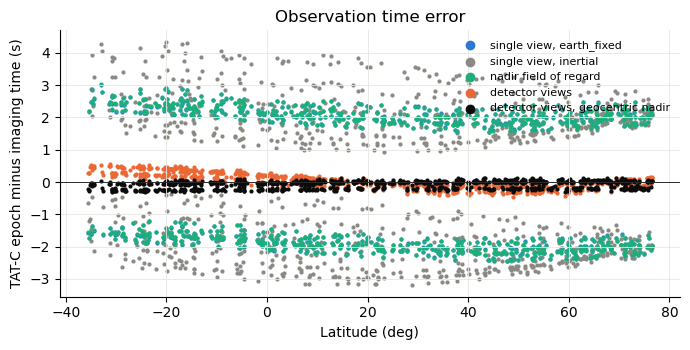

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, color in zip(dt4, [BLUE, GRAY, AQUA, ORANGE, INK]):
    if len(dt4[name]) == len(lat4):
        ax.scatter(lat4, dt4[name], s=4, color=color, label=name)
ax.axhline(0, color=INK, lw=0.6)
ax.set(xlabel="Latitude (deg)", ylabel="TAT-C epoch minus imaging time (s)", title="Observation time error")
ax.legend(frameon=False, fontsize=8, markerscale=3)
fig.tight_layout()
plt.show()

All 1,001 sampled points are observed by every representation of MSI, but their observation times differ.

* The **single view** and the **nadir field of regard** report the time a point crosses the center of the view (or passes closest to the satellite). MSI images a point about 2 s before or after that time, depending on whether an even (forward) or odd (aft) module images it: the errors form two groups near +2 and -2 s, and none exceeds about 3 s. In the inertial frame, the 3 deg yaw spreads the groups across the swath, to 4.3 s.
* The **detector views** place each module at its measured along-track view angle and report epochs within 0.42 s of the imaging time (95th percentile; median -0.02 s). The remaining error varies with latitude, from about +0.4 s in the south to -0.2 s at mid-northern latitudes: the geodetic and geocentric nadir offset of Test 2.
* With a **geocentric nadir reference**, the detector views report epochs within 0.26 s of the imaging time (95th percentile; at most 0.32 s), with no dependence on latitude. The remainder is consistent with the 0.1 deg difference in pointing between the satellites (Test 2), which these views, fit to all three, do not represent.

For time steps of 10 s or more, the single view's 2 s errors are within the integration time implied by its tailored along-track field of view, and it is the appropriate model for coverage analyses. Times accurate to a fraction of a second require the detector-level views.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. GPS ephemeris) | 0.5 km along track and 0.2 km across track and radially (95th percentile), a day or more before the TLE epoch |
| 2. Viewing geometry | cross-track field of view 21.1 deg centered on nadir in 12 detector modules; odd modules 0.9 deg aft and even modules 1.0 deg forward; detector lines perpendicular to the *Earth-fixed* velocity (yaw steered; 3.2 deg yaw in the inertial frame); pointing follows the geocentric nadir, up to 0.2 deg from the geodetic nadir (TAT-C's default) |
| 3. Swath footprints (`compute_ground_track`) | median IoU 0.957 over 122 datastrips; swath 2% wider than the all-band valid swath; 4 s (27 km) shorter in total at datastrip ends, from detector stagger |
| 4. Observation times (`collect_observations`) | single view or nadir field of regard: within 2 to 3 s (the detector stagger); detector views: within 0.42 s (95th percentile), or 0.26 s with a geocentric nadir reference |

**Single view.** A rectangular `PointedInstrument` spanning the swath, in the Earth-fixed velocity frame, reproduces the area MSI images and identifies every pass. Its observation times are within the 2 s that separates MSI's staggered detector modules from nadir, an interval shorter than the time steps typically used for coverage analyses. Because MSI is yaw steered, the default Earth-fixed velocity frame is the correct choice; the inertial frame gives nearly the same footprints but spreads the observation times.

**Detector views.** Because each `PointedInstrument` is a rigid rotation from nadir, one view per detector module, rolled and pitched to the module's measured view angles, models the focal plane layout directly and recovers imaging times to within half a second. Sentinel-2 points relative to the geocentric vertical, while TAT-C's default is the geodetic vertical, a difference of up to 0.2 deg (2.8 km along track, 0.4 s) at mid-latitudes; with a geocentric nadir reference (`nadir_reference`), the detector views recover imaging times to within about a quarter of a second at all latitudes.